# Local Inference — Mullen Fine-Tune Experiments

Runs inference on a local PlanetScope scene using any subset of the 14 trained
experiments. For each model produces:
- Probability GeoTIFF (uint16, values 0–1000, nodata=65535)
- 4-column comparison plot per model:
  - False colour (NIR-R-G)
  - Binary prediction at 0.50 threshold
  - Binary prediction at optimal threshold (loaded from shared eval CSV)
  - Probability classes: <0.95 = not water, 0.95–0.99 = probable (light blue), ≥0.99 = confident (dark blue)

## Expected directory layout
```
unet-water/
  experiments_mullen/        ← Experiments 1–6 checkpoints
  experiments_mullen_muk/    ← Experiments 7–14 checkpoints
  shared_eval/
    all_experiments_results.csv   ← optimal thresholds (from unet_shared_test_eval.ipynb)
```

---
## 0.1 Install Dependencies

In [ ]:
import subprocess, sys
pkgs = ["rasterio", "segmentation-models-pytorch"]
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + pkgs)
print("Ready")

Ready


---
## 0.2 Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount("/content/drive", force_remount=False)

Mounted at /content/drive


---
## 0.3 Configuration

Edit **this cell only** to control which models run and where the data lives.

In [ ]:
from pathlib import Path

# ── Input scene ───────────────────────────────────────────────────────────────
INPUT_PS    = Path("/content/drive/MyDrive/Research/EO-Methane/paper2/data/local_nc/PS/20240118_151037_31_2447_PS_SR.tif")
INPUT_SLOPE = Path("/content/drive/MyDrive/Research/EO-Methane/paper2/data/local_nc/slope/slope_640.tif")

# ── Output directory ──────────────────────────────────────────────────────────
OUTPUT_DIR  = Path("/content/drive/MyDrive/Research/EO-Methane/paper2/inference_local")

# ── Experiment directories ────────────────────────────────────────────────────
DRIVE_ROOT      = Path("/content/drive/MyDrive/Research/EO-Methane/paper2/")
EXP_LOCAL_DIR   = DRIVE_ROOT / "experiments_mullen"
EXP_MUK_DIR     = DRIVE_ROOT / "experiments_mullen_muk"
SHARED_EVAL_DIR = DRIVE_ROOT / "shared_eval"

# ── Models to run ─────────────────────────────────────────────────────────────
# Each entry: (experiment_name, checkpoint_dir, n_bands)
# n_bands: 4=Mullen no-slope, 5=Mullen+slope, 10=fine-tune no-slope, 11=fine-tune+slope
# Comment out or remove any experiments you don't want to run.
MODELS_TO_RUN = [
    # ── Experiments 1–6: local only ───────────────────────────────────────────
    # ("mullen_unaltered",                   EXP_LOCAL_DIR, 5),
    # ("mullen_noslope_unaltered",            EXP_LOCAL_DIR, 4),
    # ("mullen_finetune_standard",            EXP_LOCAL_DIR, 11),
    # ("mullen_finetune_aggressive",          EXP_LOCAL_DIR, 11),
    # ("mullen_noslope_finetune_standard",    EXP_LOCAL_DIR, 10),
    # ("mullen_noslope_finetune_aggressive",  EXP_LOCAL_DIR, 10),
    # # ── Experiments 7–14: Mukherjee ± local ───────────────────────────────────
    # ("mullen_muk_slope_standard",           EXP_MUK_DIR,   11),
    # ("mullen_muk_slope_aggressive",         EXP_MUK_DIR,   11),
    ("mullen_muk_noslope_standard",         EXP_MUK_DIR,   10),
    # ("mullen_muk_noslope_aggressive",       EXP_MUK_DIR,   10),
    # ("mullen_muk_local_slope_standard",     EXP_MUK_DIR,   11),
    # ("mullen_muk_local_slope_aggressive",   EXP_MUK_DIR,   11),
    ("mullen_muk_local_noslope_standard",   EXP_MUK_DIR,   10),
    # ("mullen_muk_local_noslope_aggressive", EXP_MUK_DIR,   10),
]

# ── Slope normalisation statistics ────────────────────────────────────────────
# These should match what was used during training for local NC data.
# Load from the saved stats file, or set manually if known.
SLOPE_STATS_PATH = EXP_MUK_DIR / "slope_stats.npy"

# ── Inset for plot (pixels into the scene) ────────────────────────────────────
# Set to None to skip the inset and show only the full scene
INSET_ROW  = 200
INSET_COL  = 2750
INSET_SIZE = 1024

# ── Other ─────────────────────────────────────────────────────────────────────
CHIP_SIZE  = 256
BATCH_SIZE = 1     # 1 chip at a time — avoids OOM on large scenes
SAVE_PROB_GEOTIFF = True

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Input PS:    {INPUT_PS.name}")
print(f"Input slope: {INPUT_SLOPE.name}")
print(f"Output:      {OUTPUT_DIR}")
print(f"Models:      {len(MODELS_TO_RUN)} selected")

Input PS:    20240118_151037_31_2447_PS_SR.tif
Input slope: slope_640.tif
Output:      /content/drive/MyDrive/Research/EO-Methane/paper2/inference_local
Models:      2 selected


---
## 1. Imports & Shared Utilities

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch, Rectangle
import warnings
warnings.filterwarnings("ignore")

import rasterio
from rasterio.windows import Window
import torch
import torch.nn as nn
import torch.nn.functional as F
import segmentation_models_pytorch as smp

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# ── Constants ─────────────────────────────────────────────────────────────────
BAND_REORDER      = [1, 2, 3, 5, 6, 7, 8, 9, 0, 4]
EFFICIENTNET_MEAN = 0.449
EFFICIENTNET_STD  = 0.226
N_BANDS_SLOPE     = 11
N_BANDS_NOSLOPE   = 10

# Probability threshold display colours
PROB_CMAP = mcolors.ListedColormap([
    "white",     # 0: not water (prob < 0.95)
    "#AED6F1",   # 1: probable  (0.95 ≤ prob < 0.99)
    "#1A5276",   # 2: confident (prob ≥ 0.99)
    "lightgrey", # 3: no-data
])
PROB_NORM = mcolors.BoundaryNorm([0, 1, 2, 3, 4], PROB_CMAP.N)
MASK_CMAP = mcolors.ListedColormap(["white", "steelblue", "lightgrey"])

BINARY_LEGEND = [
    Patch(facecolor="white",     edgecolor="grey", label="Not water"),
    Patch(facecolor="steelblue", edgecolor="grey", label="Water"),
    Patch(facecolor="lightgrey", edgecolor="grey", label="No data"),
]
PROB_LEGEND = [
    Patch(facecolor="white",    edgecolor="grey", label="Not water (<0.95)"),
    Patch(facecolor="#AED6F1",  edgecolor="grey", label="Probable (0.95–0.99)"),
    Patch(facecolor="#1A5276",  edgecolor="grey", label="Confident (≥0.99)"),
    Patch(facecolor="lightgrey",edgecolor="grey", label="No data"),
]

print("Imports complete.")

Device: cuda
GPU: Tesla T4
Imports complete.


---
## 2. Load Slope Stats & Optimal Thresholds

In [ ]:
# ── Slope normalisation statistics ────────────────────────────────────────────
if SLOPE_STATS_PATH.exists():
    ss = np.load(SLOPE_STATS_PATH, allow_pickle=True).item()
    LOCAL_SLOPE_MEAN = ss["local_mean"]
    LOCAL_SLOPE_STD  = ss["local_std"]
    print(f"Slope stats (local): mean={LOCAL_SLOPE_MEAN:.3f}°  std={LOCAL_SLOPE_STD:.3f}°")
else:
    # Fallback — set manually if slope_stats.npy not available
    LOCAL_SLOPE_MEAN = 0.0
    LOCAL_SLOPE_STD  = 1.0
    print("Warning: slope_stats.npy not found — using default normalisation (mean=0, std=1).")
    print("         Set LOCAL_SLOPE_MEAN and LOCAL_SLOPE_STD manually for accurate results.")

# ── Optimal thresholds from shared eval CSV ───────────────────────────────────
# Load from the combined test split, optimal threshold rows
eval_csv = SHARED_EVAL_DIR / "all_experiments_results.csv"
opt_thresholds = {}   # exp_name → float threshold

if eval_csv.exists():
    df_eval = pd.read_csv(eval_csv)
    # Optimal threshold rows have numeric threshold values (not "0.50")
    df_opt  = df_eval[
        (df_eval["test_split"] == "combined") &
        (df_eval["threshold"].astype(str) != "0.50")
    ]
    for _, row in df_opt.iterrows():
        opt_thresholds[row["name"]] = float(row["threshold"])
    print(f"Loaded optimal thresholds for {len(opt_thresholds)} experiments:")
    for name, thresh in opt_thresholds.items():
        print(f"  {name}: {thresh:.3f}")
else:
    print("Warning: all_experiments_results.csv not found.")
    print("         Optimal threshold will default to 0.50 for all models.")
    print("         Run unet_shared_test_eval.ipynb first to generate this file.")

Slope stats (local): mean=4.597°  std=5.331°
Loaded optimal thresholds for 14 experiments:
  mullen_unaltered: 0.964
  mullen_noslope_unaltered: 0.477
  mullen_finetune_standard: 0.517
  mullen_finetune_aggressive: 0.952
  mullen_noslope_finetune_standard: 0.451
  mullen_noslope_finetune_aggressive: 0.889
  mullen_muk_slope_standard: 0.444
  mullen_muk_slope_aggressive: 0.629
  mullen_muk_noslope_standard: 0.239
  mullen_muk_noslope_aggressive: 0.391
  mullen_muk_local_slope_standard: 0.321
  mullen_muk_local_slope_aggressive: 0.446
  mullen_muk_local_noslope_standard: 0.457
  mullen_muk_local_noslope_aggressive: 0.711


---
## 3. Model & Inference Utilities

In [ ]:
def build_model(n_bands: int) -> smp.Unet:
    return smp.Unet(
        encoder_name="efficientnet-b7",
        encoder_weights=None,
        in_channels=n_bands,
        classes=2,
        activation=None,
    )


def preprocess_spectral(chip: np.ndarray) -> np.ndarray:
    chip = chip.astype(np.float32)
    chip = (chip / 10000.0) * 255.0
    chip[chip == 0] = 0.5
    chip = chip / 255.0
    return (chip - EFFICIENTNET_MEAN) / EFFICIENTNET_STD


def preprocess_slope(slope: np.ndarray, mean: float, std: float) -> np.ndarray:
    slope = slope.astype(np.float32)
    slope[slope == -9999] = np.nan
    slope = np.nan_to_num(slope, nan=0.0)
    return (slope - mean) / (std + 1e-6)


def get_chip_offsets(total: int, chip_size: int) -> list:
    offsets = list(range(0, total - chip_size + 1, chip_size))
    if not offsets or offsets[-1] + chip_size < total:
        offsets.append(max(0, total - chip_size))
    return offsets


def read_chip(src, row: int, col: int, chip_size: int,
              band_indices: list = None) -> np.ndarray:
    window = Window(col, row, chip_size, chip_size)
    return src.read(
        [b+1 for b in band_indices] if band_indices else None,
        window=window, out_dtype=np.float32
    )


def predict_scene(ps_path: Path, slope_path: Path,
                  model: smp.Unet, n_bands: int,
                  slope_mean: float, slope_std: float,
                  chip_size: int = 256,
                  device=DEVICE) -> tuple:
    """
    Tile → predict → stitch a full scene.

    Returns:
        prob_map : float32 (H, W)  water probability 0–1, nan = no-data
    """
    model.eval()

    with rasterio.open(ps_path) as src:
            H, W = src.height, src.width

    # No-data mask: read slope using a window matching the PS extent
    # to guard against sub-pixel size differences after reprojection.
    with rasterio.open(slope_path) as slp_src:
        slope_raw = slp_src.read(
            1, window=Window(0, 0, W, H),
            out_shape=(H, W),
            resampling=rasterio.enums.Resampling.nearest,
            masked=False
        ).astype(np.float32)
    nodata_mask = slope_raw == -9999

    prob_map  = np.zeros((H, W), dtype=np.float32)
    count_map = np.zeros((H, W), dtype=np.uint8)

    with rasterio.open(ps_path) as ps_src, \
         rasterio.open(slope_path) as slp_src:

        for r in get_chip_offsets(H, chip_size):
            for c in get_chip_offsets(W, chip_size):

                if n_bands == 4:
                    # Mullen no-slope: B/G/R/NIR from stored indices
                    spec  = read_chip(ps_src, r, c, chip_size, [1,2,3,5])
                    chip  = preprocess_spectral(spec)              # (4,H,W)
                elif n_bands == 5:
                    # Mullen with slope: B/G/R/NIR + slope
                    spec  = read_chip(ps_src,  r, c, chip_size, [1,2,3,5])
                    slp   = read_chip(slp_src, r, c, chip_size)
                    spec  = preprocess_spectral(spec)
                    slp   = preprocess_slope(slp, slope_mean, slope_std)
                    chip  = np.concatenate([spec, slp], axis=0)   # (5,H,W)
                elif n_bands == N_BANDS_SLOPE:   # 11
                    # Fine-tuned with slope: all 10 bands + slope
                    spec  = read_chip(ps_src,  r, c, chip_size)
                    slp   = read_chip(slp_src, r, c, chip_size)
                    spec  = preprocess_spectral(spec)
                    slp   = preprocess_slope(slp, slope_mean, slope_std)
                    chip  = np.concatenate([spec, slp], axis=0)   # (11,H,W)
                else:   # 10
                    # Fine-tuned no slope: all 10 spectral/index bands
                    spec  = read_chip(ps_src, r, c, chip_size)
                    chip  = preprocess_spectral(spec)              # (10,H,W)

                chip = np.nan_to_num(chip, nan=0.0, posinf=3.0, neginf=-3.0)
                tensor = torch.from_numpy(chip).unsqueeze(0).to(device)
                with torch.no_grad():
                    prob = torch.softmax(
                        model(tensor), dim=1)[0, 1].cpu().numpy()
                prob_map[r:r+chip_size,  c:c+chip_size] += prob
                count_map[r:r+chip_size, c:c+chip_size] += 1

    avg_prob = prob_map / np.maximum(count_map, 1)
    avg_prob[nodata_mask] = np.nan
    return avg_prob


def prob_to_class_map(prob: np.ndarray) -> np.ndarray:
    """
    Convert probability map to 4-class display array:
      0 = not water (prob < 0.95)
      1 = probable  (0.95 ≤ prob < 0.99)
      2 = confident (prob ≥ 0.99)
      3 = no-data   (nan)
    """
    out = np.full_like(prob, 3, dtype=np.uint8)
    valid = ~np.isnan(prob)
    out[valid & (prob <  0.95)] = 0
    out[valid & (prob >= 0.95) & (prob < 0.99)] = 1
    out[valid & (prob >= 0.99)] = 2
    return out


def prob_to_binary(prob: np.ndarray, threshold: float) -> np.ndarray:
    """
    Threshold probability map to binary display array:
      0 = not water, 1 = water, 2 = no-data
    """
    out = np.full_like(prob, 2, dtype=np.uint8)
    valid = ~np.isnan(prob)
    out[valid & (prob <  threshold)] = 0
    out[valid & (prob >= threshold)] = 1
    return out


def save_prob_geotiff(prob: np.ndarray, reference_path: Path,
                       output_path: Path) -> None:
    """
    Save probability map as uint16 GeoTIFF.
    Values 0–1000 (divide by 1000 to recover probability), 65535 = no-data.
    """
    with rasterio.open(reference_path) as ref:
        profile = ref.profile.copy()
    profile.update(count=1, dtype="uint16", compress="lzw", nodata=65535)
    prob_uint16 = np.where(
        np.isnan(prob), 65535,
        np.clip(prob * 1000, 0, 1000)
    ).astype(np.uint16)
    with rasterio.open(output_path, "w", **profile) as dst:
        dst.write(prob_uint16[np.newaxis, ...])


print("Inference utilities defined.")

Inference utilities defined.


---
## 4. Load Scene Preview
Reads the false colour chip once — shared across all model plots.

In [ ]:
with rasterio.open(INPUT_PS) as src:
    H_FULL, W_FULL = src.height, src.width
    print(f"Scene: {INPUT_PS.name}")
    print(f"Size:  {H_FULL} × {W_FULL} px  ({src.count} bands)")
    print(f"CRS:   {src.crs}")
    print(f"Res:   {src.res}")
    # NIR(6)-R(4)-G(3) false colour — stored 1-indexed
    fc_full = src.read([6, 4, 3]).astype(np.float32).transpose(1, 2, 0)

p2, p98 = np.nanpercentile(fc_full, (2, 98))
fc_full = np.clip((fc_full - p2) / (p98 - p2 + 1e-6), 0, 1)

# Inset region
if INSET_ROW is not None:
    r0 = INSET_ROW; c0 = INSET_COL
    r1 = min(r0 + INSET_SIZE, H_FULL)
    c1 = min(c0 + INSET_SIZE, W_FULL)
    fc_inset = fc_full[r0:r1, c0:c1]
    print(f"Inset: rows {r0}:{r1}, cols {c0}:{c1}")
else:
    fc_inset = fc_full
    r0 = c0 = 0; r1 = H_FULL; c1 = W_FULL

print(f"Inset size: {fc_inset.shape[0]} × {fc_inset.shape[1]} px")

Scene: 20240118_151037_31_2447_PS_SR.tif
Size:  5492 × 6945 px  (10 bands)
CRS:   EPSG:32119
Res:   (2.99253788733686, 2.992537887336865)
Inset: rows 200:1224, cols 2750:3774
Inset size: 1024 × 1024 px


---
## 5. Run Inference Loop

Iterates over `MODELS_TO_RUN`. For each model:
1. Loads best model weights
2. Runs full-scene inference
3. Saves probability GeoTIFF
4. Produces 4-column comparison plot (false colour / binary@0.50 / binary@opt / prob classes)


── mullen_muk_noslope_standard (10-band) ────────────────────
  Loaded: mullen_muk_noslope_standard/best_model.pt
  Optimal threshold: 0.239
  Water @0.50: 27.16%  @0.239: 28.21%  @0.99: 25.87%


  Saved: 20240118_151037_31_2447_PS_SR_mullen_muk_noslope_standard_prob.tif


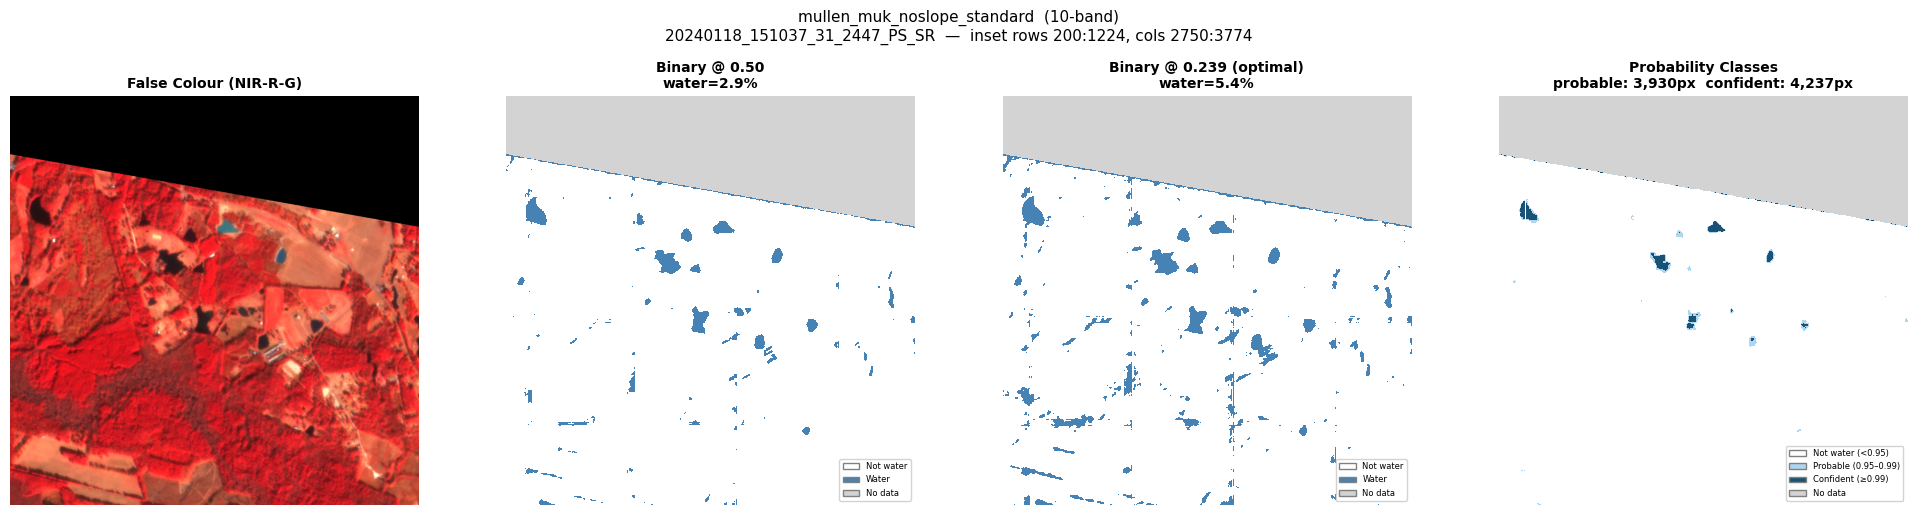

  Plot saved: 20240118_151037_31_2447_PS_SR_mullen_muk_noslope_standard_plot.png

── mullen_muk_local_noslope_standard (10-band) ────────────────────
  Loaded: mullen_muk_local_noslope_standard/best_model.pt
  Optimal threshold: 0.457
  Water @0.50: 27.43%  @0.457: 27.55%  @0.99: 25.88%


  Saved: 20240118_151037_31_2447_PS_SR_mullen_muk_local_noslope_standard_prob.tif


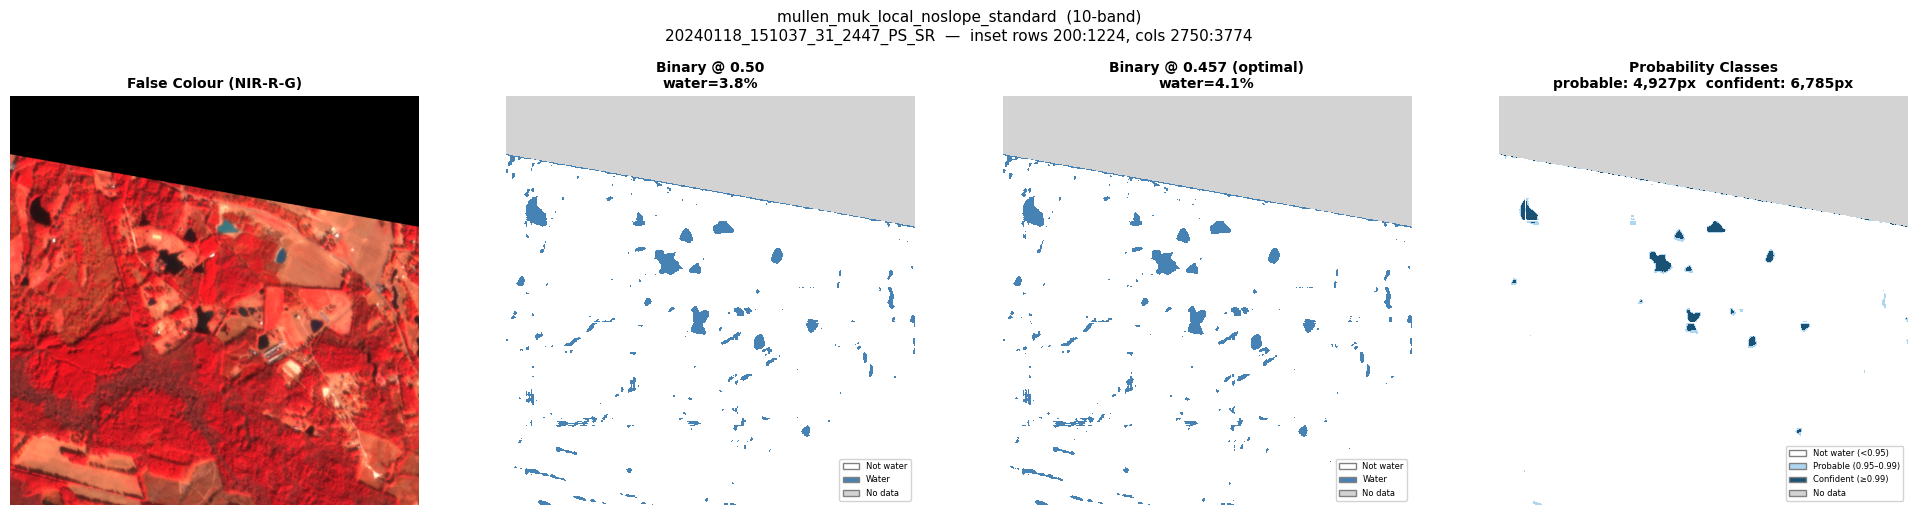

  Plot saved: 20240118_151037_31_2447_PS_SR_mullen_muk_local_noslope_standard_plot.png

Done — 2 model(s) run.


In [ ]:
scene_stem = INPUT_PS.stem
all_run = []   # (name, prob_map) stored for optional later use

for exp_name, ckpt_dir, n_bands in MODELS_TO_RUN:
    model_path = ckpt_dir / exp_name / "best_model.pt"
    if not model_path.exists():
        print(f"\n[{exp_name}] Skipping — best_model.pt not found at {model_path}")
        continue

    print(f"\n── {exp_name} ({n_bands}-band) ────────────────────")

    # ── Load model ────────────────────────────────────────────────────────────
    model = build_model(n_bands).to(DEVICE)
    model.load_state_dict(
        torch.load(model_path, map_location=DEVICE, weights_only=True))
    model.eval()
    print(f"  Loaded: {model_path.parent.name}/best_model.pt")

    # ── Run inference ─────────────────────────────────────────────────────────
    prob = predict_scene(
        INPUT_PS, INPUT_SLOPE, model, n_bands,
        LOCAL_SLOPE_MEAN, LOCAL_SLOPE_STD,
        chip_size=CHIP_SIZE, device=DEVICE
    )

    # ── Optimal threshold ─────────────────────────────────────────────────────
    opt_thresh = opt_thresholds.get(exp_name, 0.50)
    if exp_name not in opt_thresholds:
        print(f"  Warning: no optimal threshold found — using 0.50")
    print(f"  Optimal threshold: {opt_thresh:.3f}")

    # ── Water fraction stats ──────────────────────────────────────────────────
    valid = ~np.isnan(prob)
    water_05  = (prob[valid] >= 0.50).sum() / valid.sum() * 100
    water_opt = (prob[valid] >= opt_thresh).sum() / valid.sum() * 100
    water_99  = (prob[valid] >= 0.99).sum() / valid.sum() * 100
    print(f"  Water @0.50: {water_05:.2f}%  "
          f"@{opt_thresh:.3f}: {water_opt:.2f}%  "
          f"@0.99: {water_99:.2f}%")

    # ── Save probability GeoTIFF ──────────────────────────────────────────────
    if SAVE_PROB_GEOTIFF:
        prob_out = OUTPUT_DIR / f"{scene_stem}_{exp_name}_prob.tif"
        save_prob_geotiff(prob, INPUT_PS, prob_out)
        print(f"  Saved: {prob_out.name}")

    # ── Crop to inset region ──────────────────────────────────────────────────
    prob_inset = prob[r0:r1, c0:c1]

    # Prepare display arrays
    bin_05  = prob_to_binary(prob_inset, 0.50)
    bin_opt = prob_to_binary(prob_inset, opt_thresh)
    prob_cls= prob_to_class_map(prob_inset)

    w_inset_05  = (bin_opt[bin_opt != 2] == 0).sum() / \
                  max((bin_opt != 2).sum(), 1)   # just to avoid div-0
    w_05_pct    = (bin_05[bin_05   != 2] == 1).sum() / \
                  max((bin_05  != 2).sum(), 1) * 100
    w_opt_pct   = (bin_opt[bin_opt != 2] == 1).sum() / \
                  max((bin_opt != 2).sum(), 1) * 100
    n_prob_px   = (prob_cls == 1).sum()
    n_conf_px   = (prob_cls == 2).sum()

    # ── 4-column comparison plot ──────────────────────────────────────────────
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    # Col 0: False colour
    axes[0].imshow(fc_inset)
    axes[0].set_title("False Colour (NIR-R-G)",
                      fontsize=10, fontweight="bold")
    axes[0].axis("off")

    # Col 1: Binary @ 0.50
    axes[1].imshow(bin_05, cmap=MASK_CMAP, vmin=0, vmax=2,
                   interpolation="nearest")
    axes[1].set_title(f"Binary @ 0.50\nwater={w_05_pct:.1f}%",
                      fontsize=10, fontweight="bold")
    axes[1].legend(handles=BINARY_LEGEND, loc="lower right",
                   fontsize=6, framealpha=0.85)
    axes[1].axis("off")

    # Col 2: Binary @ optimal threshold
    axes[2].imshow(bin_opt, cmap=MASK_CMAP, vmin=0, vmax=2,
                   interpolation="nearest")
    axes[2].set_title(f"Binary @ {opt_thresh:.3f} (optimal)\n"
                      f"water={w_opt_pct:.1f}%",
                      fontsize=10, fontweight="bold")
    axes[2].legend(handles=BINARY_LEGEND, loc="lower right",
                   fontsize=6, framealpha=0.85)
    axes[2].axis("off")

    # Col 3: Probability classes
    axes[3].imshow(prob_cls, cmap=PROB_CMAP, norm=PROB_NORM,
                   interpolation="nearest")
    axes[3].set_title(f"Probability Classes\n"
                      f"probable: {n_prob_px:,}px  confident: {n_conf_px:,}px",
                      fontsize=10, fontweight="bold")
    axes[3].legend(handles=PROB_LEGEND, loc="lower right",
                   fontsize=6, framealpha=0.85)
    axes[3].axis("off")

    plt.suptitle(
        f"{exp_name}  ({n_bands}-band)\n"
        f"{scene_stem}  —  inset rows {r0}:{r1}, cols {c0}:{c1}",
        fontsize=11, y=1.02
    )
    plt.tight_layout()
    fig_path = OUTPUT_DIR / f"{scene_stem}_{exp_name}_plot.png"
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Plot saved: {fig_path.name}")

    all_run.append((exp_name, prob))

    # Free GPU memory between models
    del model
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

print(f"\nDone — {len(all_run)} model(s) run.")

---
## 6. Multi-Model Comparison Plot (optional)

If you ran multiple models, this cell produces a grid showing the probability
class map for every model side by side — useful for quick visual comparison
of how different training strategies affect predictions on the same scene.

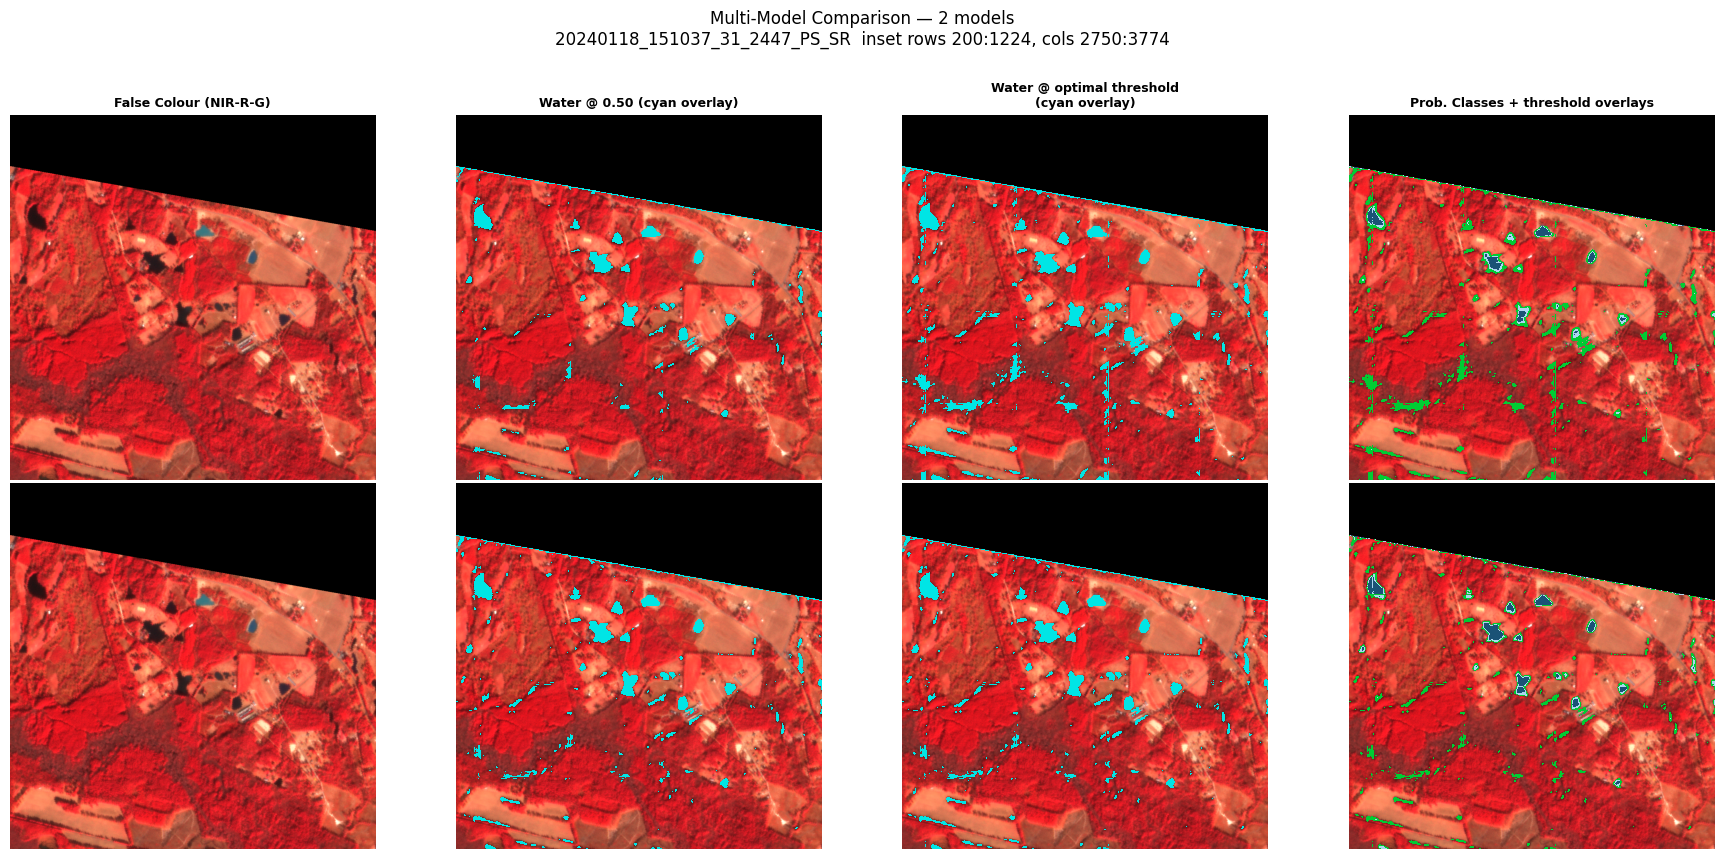

Saved: 20240118_151037_31_2447_PS_SR_multimodel_comparison.png


In [ ]:
if len(all_run) < 2:
    print("Only one model was run — skipping multi-model comparison plot.")
else:
    n_models = len(all_run)
    n_cols   = 4
    fig, axes = plt.subplots(n_models, n_cols,
                              figsize=(4.5 * n_cols, 4.5 * n_models),
                              squeeze=False)

    col_titles = [
        "False Colour (NIR-R-G)",
        "Water @ 0.50 (cyan overlay)",
        "Water @ optimal threshold\n(cyan overlay)",
        "Prob. Classes + threshold overlays",
    ]
    for ax, title in zip(axes[0], col_titles):
        ax.set_title(title, fontsize=9, fontweight="bold", pad=6)

    for row_i, (exp_name, prob) in enumerate(all_run):
        prob_inset = prob[r0:r1, c0:c1]
        opt_thresh = opt_thresholds.get(exp_name, 0.50)
        valid      = ~np.isnan(prob_inset)

        water_05  = valid & (prob_inset >= 0.50)
        water_opt = valid & (prob_inset >= opt_thresh)

        # ── Col 0: False colour ───────────────────────────────────────────────
        axes[row_i, 0].imshow(fc_inset)
        axes[row_i, 0].set_ylabel(
            exp_name.replace("mullen_", "").replace("_", "\n"),
            fontsize=7, labelpad=6)
        axes[row_i, 0].axis("off")

        # ── Col 1: 0.50 threshold — cyan overlay on false colour ──────────────
        axes[row_i, 1].imshow(fc_inset)
        cyan_05 = np.zeros((*fc_inset.shape[:2], 4), dtype=np.float32)
        cyan_05[water_05] = [0.0, 0.9, 0.9, 1]   # cyan, semi-transparent
        axes[row_i, 1].imshow(cyan_05, interpolation="nearest")
        w_05_pct = water_05.sum() / max(valid.sum(), 1) * 100
        axes[row_i, 1].set_xlabel(f"water={w_05_pct:.1f}%", fontsize=7)
        axes[row_i, 1].axis("off")

        # ── Col 2: Optimal threshold — cyan overlay on false colour ───────────
        axes[row_i, 2].imshow(fc_inset)
        cyan_opt = np.zeros((*fc_inset.shape[:2], 4), dtype=np.float32)
        cyan_opt[water_opt] = [0.0, 0.9, 0.9, 1]  # same cyan
        axes[row_i, 2].imshow(cyan_opt, interpolation="nearest")
        w_opt_pct = water_opt.sum() / max(valid.sum(), 1) * 100
        axes[row_i, 2].set_xlabel(
            f"thresh={opt_thresh:.3f}  water={w_opt_pct:.1f}%", fontsize=7)
        axes[row_i, 2].axis("off")

        # ── Col 3: Layered map ────────────────────────────────────────────────
        # Layer order (bottom to top):
        #   1. Optimal threshold binary (base)      — cyan
        #   2. 0.50 threshold pixels only           — green (marginal detections)
        #   3. Probable water (0.95–0.99)           — light blue
        #   4. Confident water (≥0.99)              — dark blue

        # Layer 1 base: optimal threshold binary on false colour
        axes[row_i, 3].imshow(fc_inset)
        base_ov = np.zeros((*fc_inset.shape[:2], 4), dtype=np.float32)
        base_ov[water_opt] = [0, 0.8, 0.2, 1]   # cyan for opt threshold
        axes[row_i, 3].imshow(base_ov, interpolation="nearest")

        # Layer 2: pixels water at 0.50 but NOT at optimal threshold
        # These are marginal detections below the calibrated threshold
        green_only = water_05 & ~water_opt
        green_ov   = np.zeros((*fc_inset.shape[:2], 4), dtype=np.float32)
        green_ov[green_only] = [0.6, 0.1, 0.8, 0.55]  # green
        axes[row_i, 3].imshow(green_ov, interpolation="nearest")

        # Layer 3: probable water (0.95 ≤ prob < 0.99) — light blue
        prob_cls   = prob_to_class_map(prob_inset)
        probable   = prob_cls == 1
        prob_ov    = np.zeros((*fc_inset.shape[:2], 4), dtype=np.float32)
        prob_ov[probable] = [0.682, 0.839, 0.945, 1]  # #AED6F1 as float
        axes[row_i, 3].imshow(prob_ov, interpolation="nearest")

        # Layer 4: confident water (≥0.99) — dark blue
        confident  = prob_cls == 2
        conf_ov    = np.zeros((*fc_inset.shape[:2], 4), dtype=np.float32)
        conf_ov[confident] = [0.102, 0.322, 0.463, 1]  # #1A5276 as float
        axes[row_i, 3].imshow(conf_ov, interpolation="nearest")

        n_prob = probable.sum()
        n_conf = confident.sum()
        axes[row_i, 3].set_xlabel(
            f"probable: {n_prob:,}px  confident: {n_conf:,}px", fontsize=7)
        axes[row_i, 3].axis("off")

    # # Shared legend
    # legend_elements = [
    #     Patch(facecolor=(0.0, 0.9, 0.9, 1),   edgecolor="grey",
    #           label="Water @ 0.50 (cyan, cols 1-2)"),
    #     Patch(facecolor=(0.0, 0.9, 0.9, 1),   edgecolor="grey",
    #           label="Water @ optimal threshold (cyan base, col 4)"),
    #     Patch(facecolor=(0.0, 0.85, 0.2, 1), edgecolor="grey",
    #           label="Water @ 0.50 only — marginal (green, col 4)"),
    #     Patch(facecolor="#AED6F1",               edgecolor="grey",
    #           label="Probable water 0.95–0.99 (light blue, col 4)"),
    #     Patch(facecolor="#1A5276",               edgecolor="grey",
    #           label="Confident water ≥0.99 (dark blue, col 4)"),
    #     Patch(facecolor="lightgrey",             edgecolor="grey",
    #           label="No data"),
    # ]
    # fig.legend(handles=legend_elements, loc="lower center", ncol=4,
    #            fontsize=7.5, framealpha=0.9, bbox_to_anchor=(0.5, 0.0))

    plt.suptitle(
        f"Multi-Model Comparison — {len(all_run)} models\n"
        f"{scene_stem}  inset rows {r0}:{r1}, cols {c0}:{c1}",
        fontsize=12, y=1.01
    )
    plt.tight_layout(rect=[0, 0.06, 1, 1])
    out_path = OUTPUT_DIR / f"{scene_stem}_multimodel_comparison.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out_path.name}")